# Bilionários do Mundo — Análise Exploratória de Dados (2023)

## Sobre este Notebook

| Item | Detalhe |
|---|---|
| **Dataset** | Billionaires Statistics Dataset — Kaggle (2023) |
| **Registros** | 2.640 bilionários |
| **Variáveis** | 35 colunas |
| **Autor** | Yan |
| **Disciplina** | EMC0128/EMC0467 — IA e AIoT — UFG |
| **Professor** | Adriano César Santana |

---

## Perguntas que este notebook responde

1. O gênero influencia o patrimônio?
2. Quais países concentram mais riqueza?
3. Riqueza herdada ou construída — qual domina?
4. Setor de atuação determina o tamanho da fortuna?
5. Como idade, gênero e origem interagem para formar bilionários?

---

## Estrutura

```
1. Setup e Carregamento
2. Limpeza e Preparação
3. Análise Univariada (Matplotlib)
4. Análise Multivariada (Seaborn)
5. Estudo de Caso — 4 Perguntas de Negócio
6. Análise Combinada
7. Resumo Executivo
```

## 1. Setup e Carregamento

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Paleta e tema consistentes ─────────────────────────────────────────────
PALETTE_MAIN  = ['#2E86AB', '#E63946', '#52B788', '#F4A261', '#A23B72']
PALETTE_GEN   = {'M': '#2E86AB', 'F': '#E63946'}
PALETTE_ORIG  = {'Autonomo': '#52B788', 'Herdeiro': '#E63946'}
BG_COLOR      = '#F8F9FA'

plt.rcParams.update({
    'figure.facecolor'  : BG_COLOR,
    'axes.facecolor'    : BG_COLOR,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.25,
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 11,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'figure.figsize'    : (12, 6),
})

# ── Carregamento ───────────────────────────────────────────────────────────
df = pd.read_csv('Billionaires Statistics Dataset.csv', encoding='utf-8-sig')
df.rename(columns={df.columns[0]: 'rank'}, inplace=True)

print(f"✓ Dataset carregado  |  {df.shape[0]:,} registros  |  {df.shape[1]} colunas")
df[['rank','finalWorth','category','personName','age','country','gender','selfMade']].head()

✓ Dataset carregado  |  2,640 registros  |  35 colunas


,rank,finalWorth,category,personName,age,country,gender,selfMade
0,1,211000,Fashion & Retail,Bernard Arnault & family,74.0,France,M,False
1,2,180000,Automotive,Elon Musk,51.0,United States,M,True
2,3,114000,Technology,Jeff Bezos,59.0,United States,M,True
3,4,107000,Technology,Larry Ellison,78.0,United States,M,True
4,5,106000,Finance & Investments,Warren Buffett,92.0,United States,M,True


## 2. Limpeza e Preparação

### Decisões de limpeza

| Ação | Justificativa |
|---|---|
| Drop de linhas sem `age` ou `finalWorth` | Variáveis centrais da análise |
| `gender` nulo → `'Outro'` | Evita perda de registros |
| `selfMade` → labels legíveis | Facilita leitura dos gráficos |
| Criação de `faixa_etaria` | Análise categórica de idade |
| Criação de `faixa_patrimonio` | Segmentação de riqueza |

In [2]:
# ── Limpeza ────────────────────────────────────────────────────────────────
df_limpo = df.copy()
df_limpo = df_limpo.dropna(subset=['age', 'finalWorth'])
df_limpo['gender'] = df_limpo['gender'].fillna('Outro')

df_limpo['origem_riqueza'] = df_limpo['selfMade'].map({
    True: 'Autonomo', False: 'Herdeiro'
})

df_limpo['faixa_etaria'] = pd.cut(
    df_limpo['age'],
    bins  = [0,  40,  60,  80, 120],
    labels= ['< 40', '40-60', '60-80', '80+']
)

df_limpo['faixa_patrimonio'] = pd.cut(
    df_limpo['finalWorth'],
    bins  = [0, 2000, 5000, 20000, 999999],
    labels= ['1-2 Bi', '2-5 Bi', '5-20 Bi', '20 Bi+']
)

# Top 5 países para análises focadas
TOP5 = df_limpo['country'].value_counts().head(5).index.tolist()
df_top5 = df_limpo[df_limpo['country'].isin(TOP5)].copy()

# ── Sumário ────────────────────────────────────────────────────────────────
print("─" * 50)
print(f"  Registros finais   : {len(df_limpo):,}")
print(f"  Patrimônio médio   : ${df_limpo['finalWorth'].mean():,.0f}M")
print(f"  Patrimônio mediano : ${df_limpo['finalWorth'].median():,.0f}M")
print(f"  Idade média        : {df_limpo['age'].mean():.1f} anos")
print(f"  % Autônomos        : {df_limpo['selfMade'].mean():.1%}")
print(f"  % Masculino        : {(df_limpo['gender']=='M').mean():.1%}")
print("─" * 50)

──────────────────────────────────────────────────
  Registros finais   : 2,575
  Patrimônio médio   : $4,679M
  Patrimônio mediano : $2,400M
  Idade média        : 65.1 anos
  % Autônomos        : 69.4%
  % Masculino        : 88.1%
──────────────────────────────────────────────────


## 3. Análise Univariada — Matplotlib

> Exploramos cada variável individualmente antes de cruzá-las.

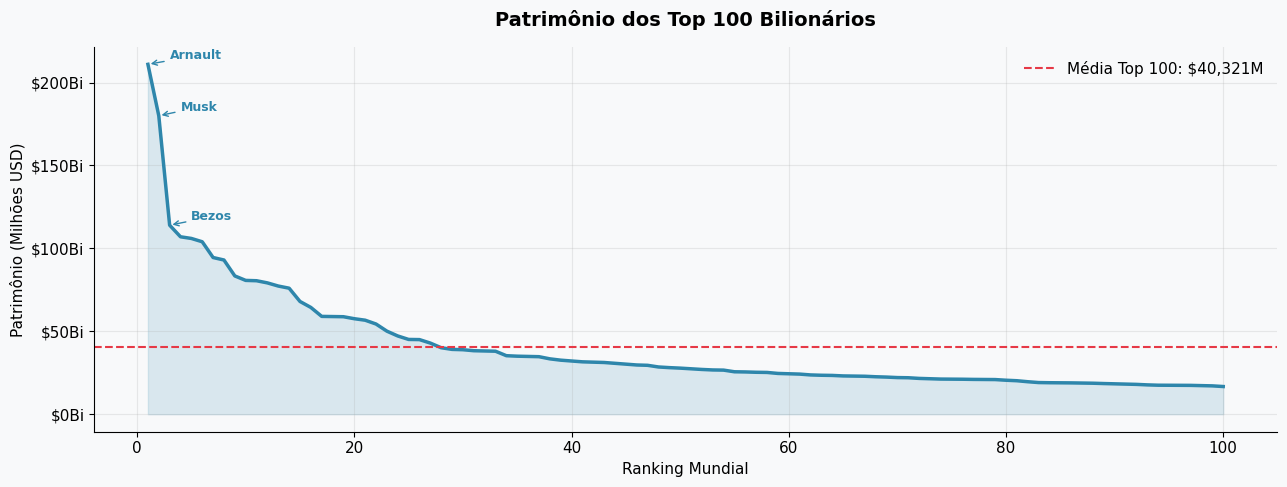

Concentração: Top 10 detêm 9.7% de toda a riqueza do dataset


In [3]:
# ── Linha: Queda do patrimônio ao longo do ranking ────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(BG_COLOR)

top100 = df_limpo.nsmallest(100, 'rank')
ax.fill_between(top100['rank'], top100['finalWorth'], alpha=0.15, color='#2E86AB')
ax.plot(top100['rank'], top100['finalWorth'], color='#2E86AB', linewidth=2.5)

# Anotações dos top 3
for _, row in top100.head(3).iterrows():
    ax.annotate(
        row['personName'].split('&')[0].strip().split()[-1],
        xy=(row['rank'], row['finalWorth']),
        xytext=(row['rank'] + 2, row['finalWorth'] + 3000),
        fontsize=9, color='#2E86AB', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#2E86AB', lw=1)
    )

media = top100['finalWorth'].mean()
ax.axhline(media, color='#E63946', linestyle='--', linewidth=1.5,
           label=f'Média Top 100: ${media:,.0f}M')

ax.set_title('Patrimônio dos Top 100 Bilionários', pad=15)
ax.set_xlabel('Ranking Mundial')
ax.set_ylabel('Patrimônio (Milhões USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}Bi'))
ax.legend(framealpha=0)
plt.tight_layout()
plt.show()

print(f"Concentração: Top 10 detêm {top100.head(10)['finalWorth'].sum()/df_limpo['finalWorth'].sum():.1%} de toda a riqueza do dataset")

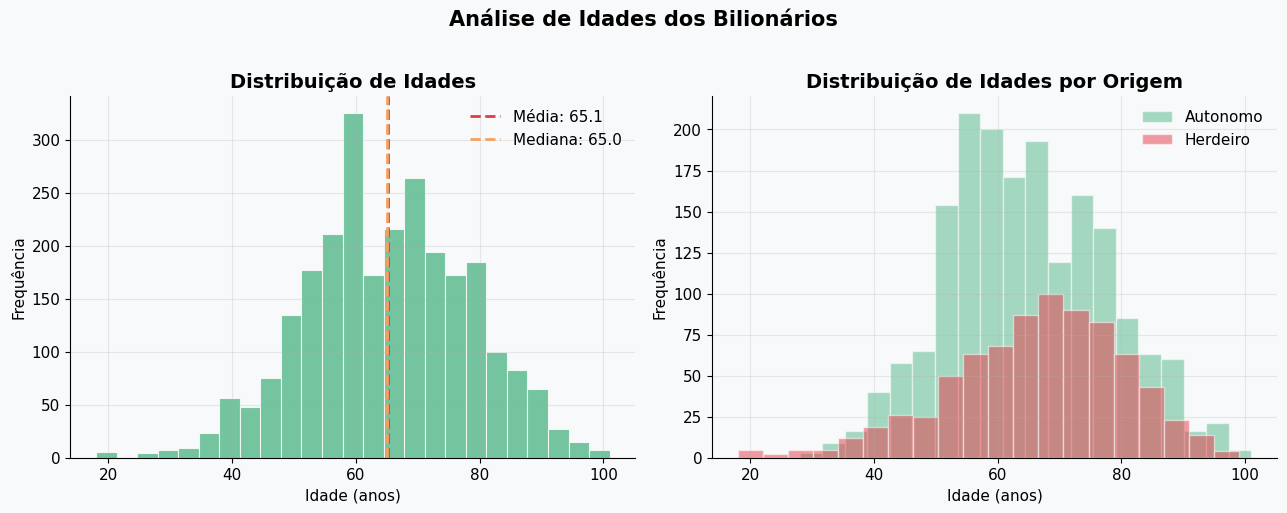

In [4]:
# ── Histograma: Distribuição de idades ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(BG_COLOR)

# Histograma geral
ax1.hist(df_limpo['age'], bins=25, color='#52B788', alpha=0.8,
         edgecolor='white', linewidth=0.8)
ax1.axvline(df_limpo['age'].mean(),   color='#E63946', linestyle='--', lw=2,
            label=f"Média: {df_limpo['age'].mean():.1f}")
ax1.axvline(df_limpo['age'].median(), color='#F4A261', linestyle='--', lw=2,
            label=f"Mediana: {df_limpo['age'].median():.1f}")
ax1.set_title('Distribuição de Idades')
ax1.set_xlabel('Idade (anos)')
ax1.set_ylabel('Frequência')
ax1.legend(framealpha=0)

# KDE por origem
for origem, cor in PALETTE_ORIG.items():
    sub = df_limpo[df_limpo['origem_riqueza'] == origem]['age'].dropna()
    ax2.hist(sub, bins=20, alpha=0.5, color=cor, label=origem, edgecolor='white')
ax2.set_title('Distribuição de Idades por Origem')
ax2.set_xlabel('Idade (anos)')
ax2.set_ylabel('Frequência')
ax2.legend(framealpha=0)

plt.suptitle('Análise de Idades dos Bilionários', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

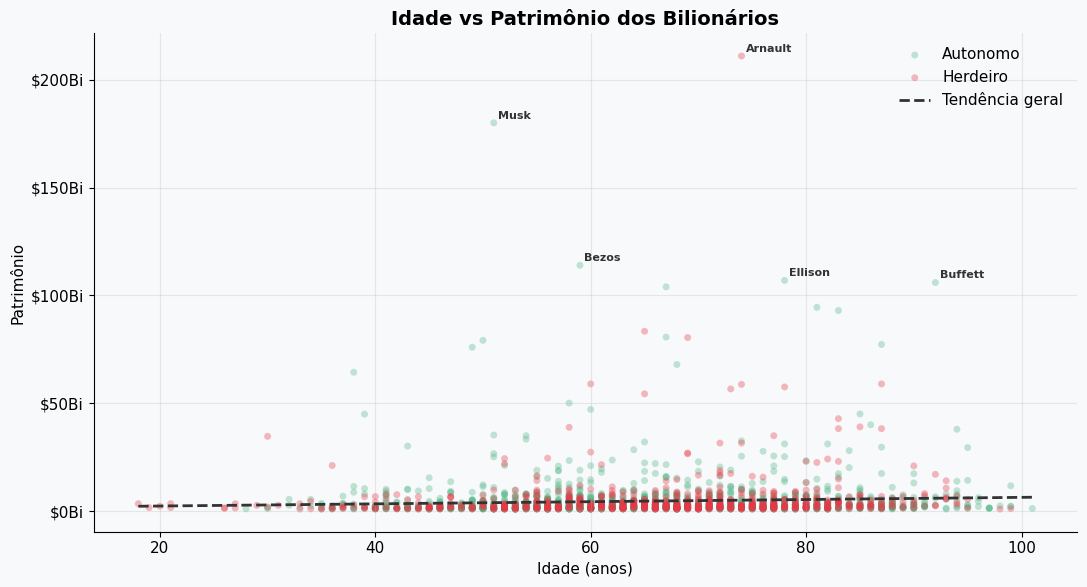

Correlação idade × patrimônio: r = 0.067  →  fraca
Insight: idade explica muito pouco da variação de riqueza


In [5]:
# ── Dispersão: Idade vs Patrimônio ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(BG_COLOR)

for origem, cor in PALETTE_ORIG.items():
    sub = df_limpo[df_limpo['origem_riqueza'] == origem]
    ax.scatter(sub['age'], sub['finalWorth'],
               c=cor, alpha=0.35, s=25, label=origem, edgecolors='none')

# Linha de tendência geral
z = np.polyfit(df_limpo['age'], df_limpo['finalWorth'], 1)
x_line = np.linspace(df_limpo['age'].min(), df_limpo['age'].max(), 200)
ax.plot(x_line, np.poly1d(z)(x_line), color='#333', lw=2,
        linestyle='--', label='Tendência geral')

# Destaque top 5
for _, row in df_limpo.nsmallest(5,'rank').iterrows():
    ax.annotate(row['personName'].split('&')[0].strip().split()[-1],
                xy=(row['age'], row['finalWorth']),
                fontsize=8, color='#333', fontweight='bold',
                xytext=(3, 3), textcoords='offset points')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}Bi'))
ax.set_title('Idade vs Patrimônio dos Bilionários')
ax.set_xlabel('Idade (anos)')
ax.set_ylabel('Patrimônio')
ax.legend(framealpha=0)
plt.tight_layout()
plt.show()

r = df_limpo['age'].corr(df_limpo['finalWorth'])
print(f"Correlação idade × patrimônio: r = {r:.3f}  →  {'fraca' if abs(r)<0.3 else 'moderada'}")
print("Insight: idade explica muito pouco da variação de riqueza")

## 4. Análise Multivariada — Seaborn

> Cruzamos variáveis para revelar padrões mais profundos.

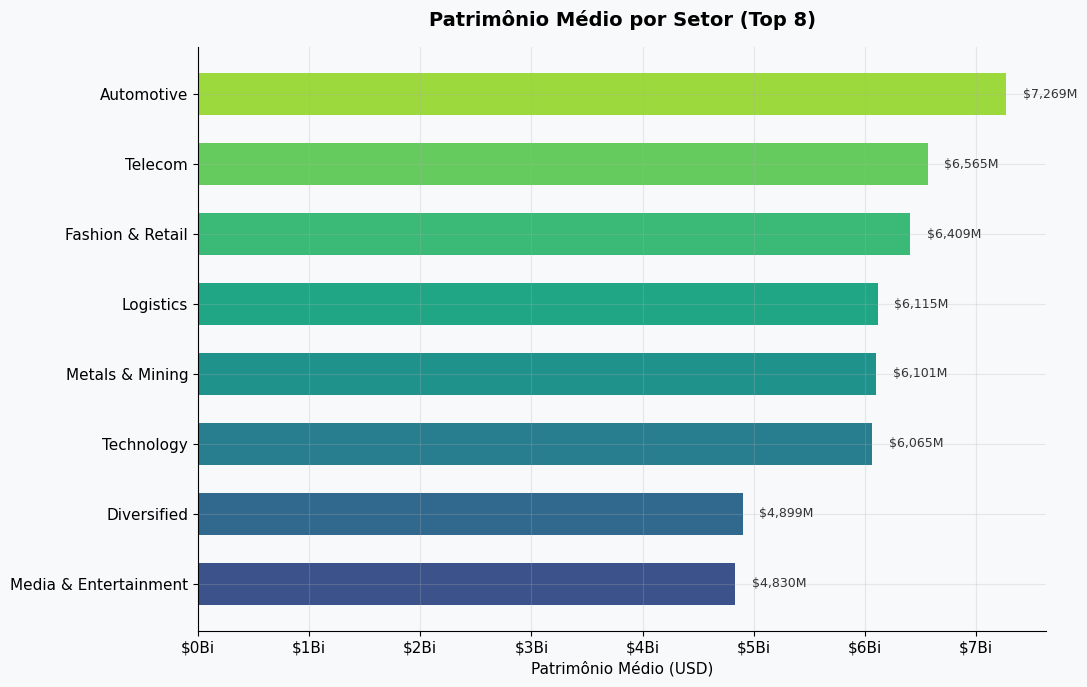

In [6]:
# ── Barplot horizontal: Patrimônio médio por setor ────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(BG_COLOR)

top8_cat = (df_limpo.groupby('category')['finalWorth']
            .mean().nlargest(8).sort_values())

colors = plt.cm.viridis(np.linspace(0.25, 0.85, len(top8_cat)))
bars = ax.barh(top8_cat.index, top8_cat.values, color=colors, edgecolor='none', height=0.6)

# Rótulos nas barras
for bar, val in zip(bars, top8_cat.values):
    ax.text(val + 150, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}M', va='center', fontsize=9, color='#333')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}Bi'))
ax.set_title('Patrimônio Médio por Setor (Top 8)', pad=15)
ax.set_xlabel('Patrimônio Médio (USD)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

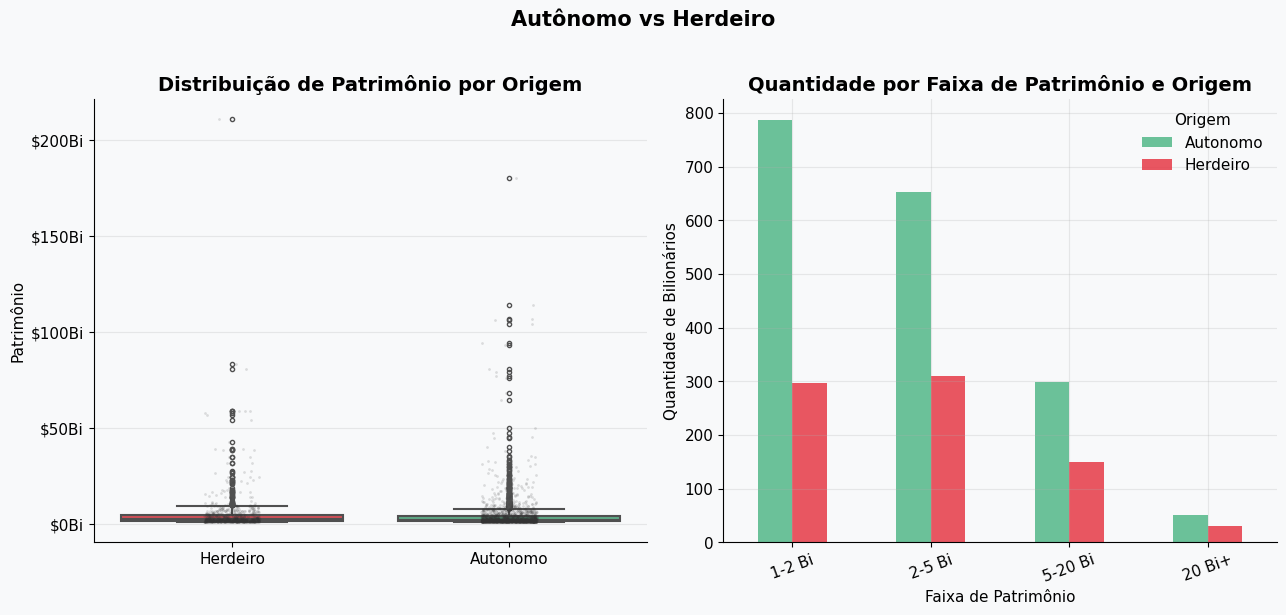

Autonomo: n=1,788 | mediana=$2,200M | média=$4,502M
Herdeiro: n=787 | mediana=$2,600M | média=$5,082M


In [7]:
# ── Boxplot: Distribuição por origem ──────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig.patch.set_facecolor(BG_COLOR)

# Boxplot
sns.boxplot(x='origem_riqueza', y='finalWorth', hue='origem_riqueza',
            data=df_limpo, palette=PALETTE_ORIG, ax=ax1,
            linewidth=1.5, legend=False, fliersize=3)
sns.stripplot(x='origem_riqueza', y='finalWorth', data=df_limpo,
              color='#333', alpha=0.15, size=2, ax=ax1)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}Bi'))
ax1.set_title('Distribuição de Patrimônio por Origem')
ax1.set_xlabel('')
ax1.set_ylabel('Patrimônio')

# Contagem por faixa de patrimônio e origem
faixa_origem = (df_limpo.groupby(['faixa_patrimonio','origem_riqueza'], observed=True)
                .size().unstack(fill_value=0))
faixa_origem.plot(kind='bar', ax=ax2,
                  color=[PALETTE_ORIG[c] for c in faixa_origem.columns],
                  alpha=0.85, edgecolor='none')
ax2.set_title('Quantidade por Faixa de Patrimônio e Origem')
ax2.set_xlabel('Faixa de Patrimônio')
ax2.set_ylabel('Quantidade de Bilionários')
ax2.tick_params(axis='x', rotation=20)
ax2.legend(title='Origem', framealpha=0)

plt.suptitle('Autônomo vs Herdeiro', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

for o in ['Autonomo','Herdeiro']:
    d = df_limpo[df_limpo['origem_riqueza']==o]['finalWorth']
    print(f"{o}: n={len(d):,} | mediana=${d.median():,.0f}M | média=${d.mean():,.0f}M")

Gerando pairplot...


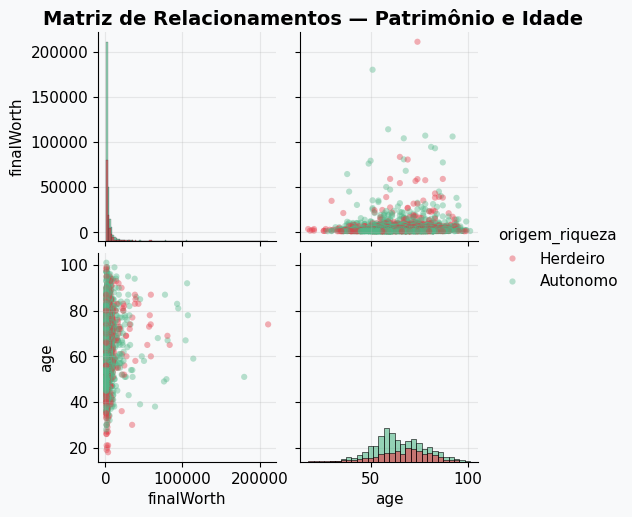


Correlações:
            finalWorth    age
finalWorth       1.000  0.067
age              0.067  1.000


In [8]:
# ── Pairplot refinado ─────────────────────────────────────────────────────
print("Gerando pairplot...")
df_pair = df_limpo[['finalWorth','age','origem_riqueza']].dropna()

g = sns.pairplot(df_pair, hue='origem_riqueza',
                 palette=PALETTE_ORIG,
                 plot_kws={'alpha': 0.4, 's': 20, 'edgecolor': 'none'},
                 diag_kws={'alpha': 0.6},
                 diag_kind='hist')
g.fig.suptitle('Matriz de Relacionamentos — Patrimônio e Idade',
               y=1.02, fontsize=14, fontweight='bold')
plt.show()

print("\nCorrelações:")
print(df_limpo[['finalWorth','age']].corr().round(3))

## 5. Estudo de Caso — Quem São os Bilionários?

### Quatro perguntas de negócio:

| # | Pergunta | Hipótese |
|---|---|---|
| 1 | O gênero influencia o patrimônio? | Homens dominam em número, não necessariamente em riqueza média |
| 2 | Quais países concentram mais riqueza? | EUA e China lideram |
| 3 | Idade e origem se relacionam? | Herdeiros são mais jovens em média |
| 4 | Setor determina tamanho da fortuna? | Tech e Finance produzem as maiores fortunas |

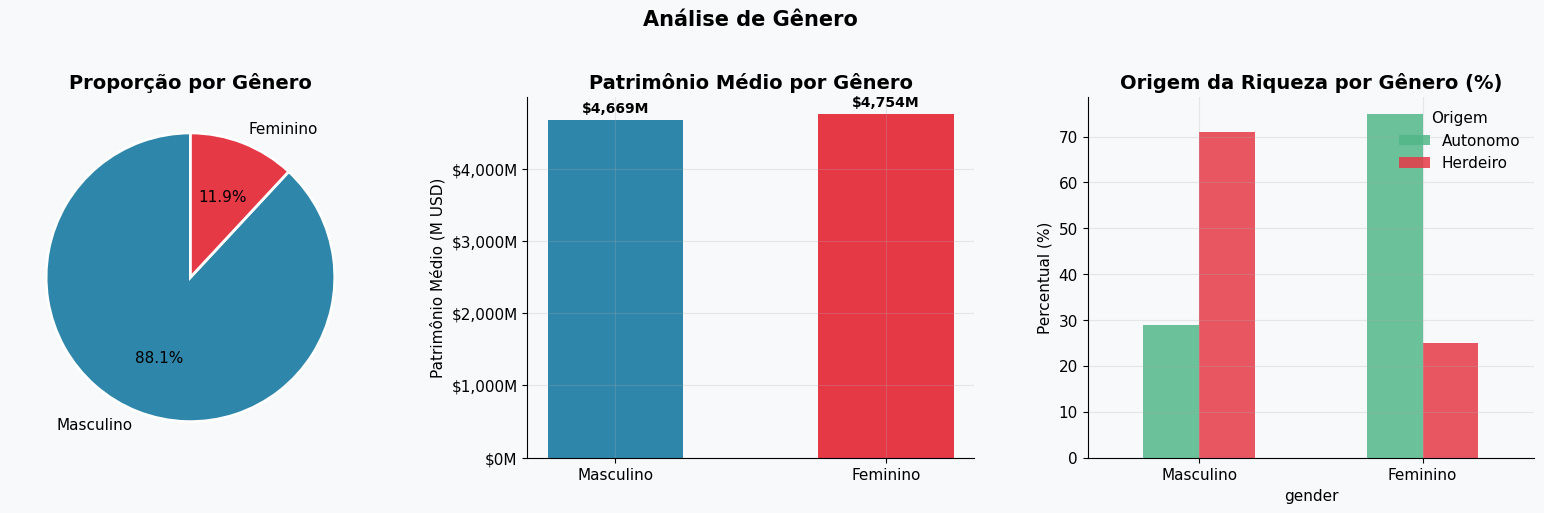

Homens: 2,268 (88.1%)
Mulheres: 307 (11.9%)

Insight: mulheres bilionárias têm patrimônio médio maior que homens


In [9]:
# ── Pergunta 1: Gênero ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(BG_COLOR)

generos = df_limpo[df_limpo['gender'].isin(['M','F'])]

# Contagem
contagem = generos['gender'].value_counts()
axes[0].pie(contagem.values, labels=['Masculino','Feminino'],
            colors=[PALETTE_GEN['M'], PALETTE_GEN['F']],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Proporção por Gênero')

# Patrimônio médio
media_gen = generos.groupby('gender')['finalWorth'].mean()
bars = axes[1].bar(['Masculino','Feminino'],
                   [media_gen['M'], media_gen['F']],
                   color=[PALETTE_GEN['M'], PALETTE_GEN['F']],
                   edgecolor='none', width=0.5)
for bar, val in zip(bars, [media_gen['M'], media_gen['F']]):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+100,
                 f'${val:,.0f}M', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Patrimônio Médio por Gênero')
axes[1].set_ylabel('Patrimônio Médio (M USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}M'))

# Origem por gênero
orig_gen = (generos.groupby(['gender','origem_riqueza'])
            .size().unstack(fill_value=0))
orig_gen_pct = orig_gen.div(orig_gen.sum(axis=1), axis=0) * 100
orig_gen_pct.plot(kind='bar', ax=axes[2],
                  color=[PALETTE_ORIG[c] for c in orig_gen_pct.columns],
                  edgecolor='none', alpha=0.85)
axes[2].set_xticklabels(['Masculino','Feminino'], rotation=0)
axes[2].set_title('Origem da Riqueza por Gênero (%)')
axes[2].set_ylabel('Percentual (%)')
axes[2].legend(title='Origem', framealpha=0)

plt.suptitle('Análise de Gênero', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Homens: {(generos['gender']=='M').sum():,} ({(generos['gender']=='M').mean():.1%})")
print(f"Mulheres: {(generos['gender']=='F').sum():,} ({(generos['gender']=='F').mean():.1%})")
print(f"\nInsight: mulheres bilionárias têm patrimônio médio {'maior' if media_gen['F']>media_gen['M'] else 'menor'} que homens")

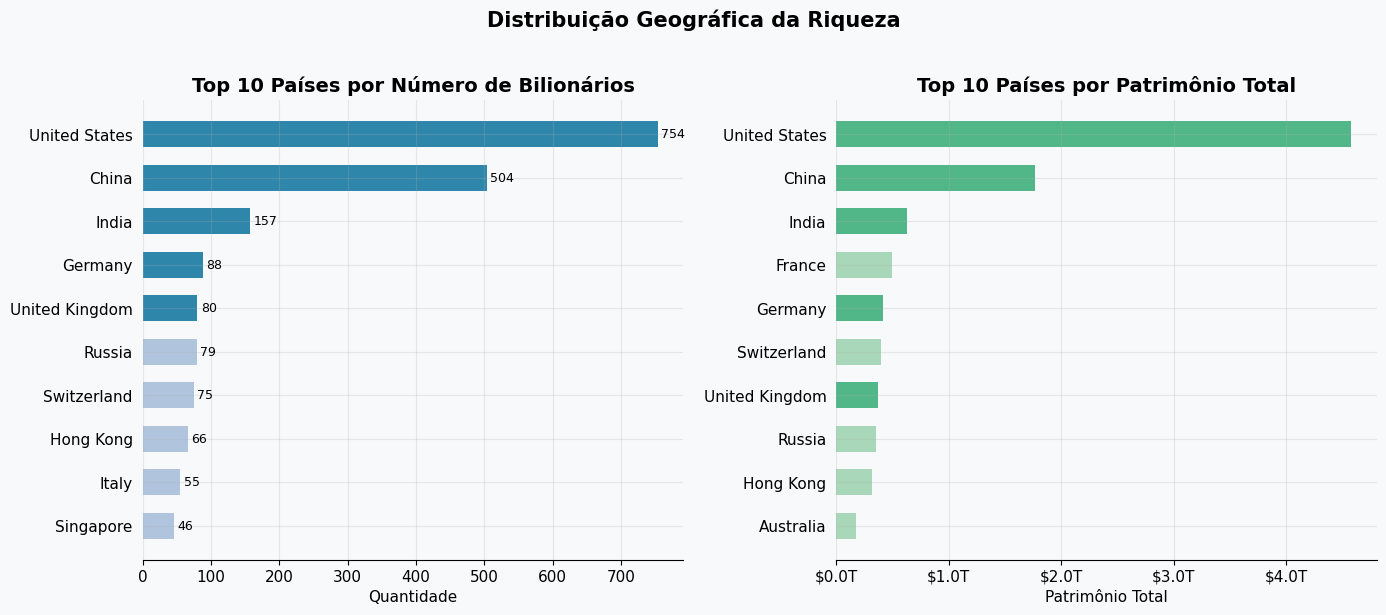

EUA concentra 38.0% de toda a riqueza do dataset


In [10]:
# ── Pergunta 2: Países ────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG_COLOR)

# Quantidade
top10_n = df_limpo['country'].value_counts().head(10)
cores_n = ['#2E86AB' if c in TOP5 else '#B0C4DE' for c in top10_n.index]
ax1.barh(top10_n.index[::-1], top10_n.values[::-1],
         color=cores_n[::-1], edgecolor='none', height=0.6)
for i, (pais, val) in enumerate(zip(top10_n.index[::-1], top10_n.values[::-1])):
    ax1.text(val+5, i, str(val), va='center', fontsize=9)
ax1.set_title('Top 10 Países por Número de Bilionários')
ax1.set_xlabel('Quantidade')
ax1.spines['left'].set_visible(False)
ax1.tick_params(left=False)

# Patrimônio total
top10_w = df_limpo.groupby('country')['finalWorth'].sum().nlargest(10)
cores_w = ['#52B788' if c in TOP5 else '#A8D8B9' for c in top10_w.index]
ax2.barh(top10_w.index[::-1], top10_w.values[::-1],
         color=cores_w[::-1], edgecolor='none', height=0.6)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}T'))
ax2.set_title('Top 10 Países por Patrimônio Total')
ax2.set_xlabel('Patrimônio Total')
ax2.spines['left'].set_visible(False)
ax2.tick_params(left=False)

plt.suptitle('Distribuição Geográfica da Riqueza', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

pct_eua = df_limpo[df_limpo['country']=='United States']['finalWorth'].sum() / df_limpo['finalWorth'].sum()
print(f"EUA concentra {pct_eua:.1%} de toda a riqueza do dataset")

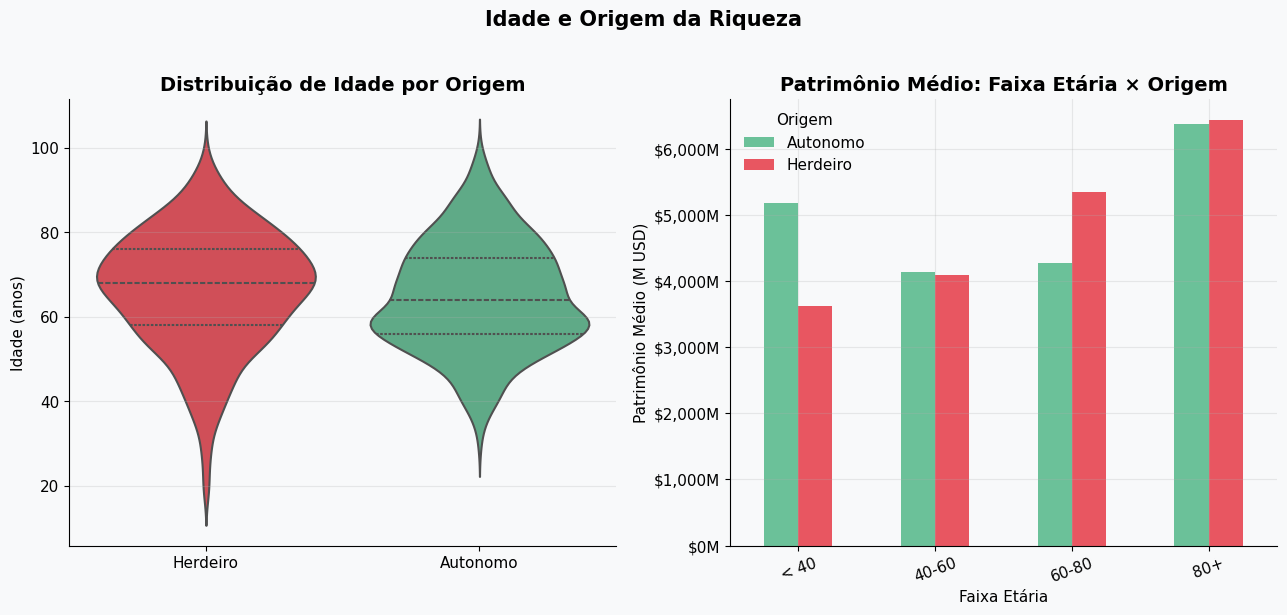

Autonomo: idade mediana = 64 anos
Herdeiro: idade mediana = 68 anos


In [11]:
# ── Pergunta 3: Idade e Origem ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig.patch.set_facecolor(BG_COLOR)

# Violinplot
sns.violinplot(x='origem_riqueza', y='age', hue='origem_riqueza',
               data=df_limpo, palette=PALETTE_ORIG,
               ax=ax1, legend=False, linewidth=1.5, inner='quartile')
ax1.set_title('Distribuição de Idade por Origem')
ax1.set_xlabel('')
ax1.set_ylabel('Idade (anos)')

# Patrimônio médio por faixa etária e origem
pivot = (df_limpo.groupby(['faixa_etaria','origem_riqueza'], observed=True)['finalWorth']
         .mean().unstack(fill_value=0))
pivot.plot(kind='bar', ax=ax2,
           color=[PALETTE_ORIG[c] for c in pivot.columns],
           alpha=0.85, edgecolor='none')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}M'))
ax2.set_title('Patrimônio Médio: Faixa Etária × Origem')
ax2.set_xlabel('Faixa Etária')
ax2.set_ylabel('Patrimônio Médio (M USD)')
ax2.tick_params(axis='x', rotation=20)
ax2.legend(title='Origem', framealpha=0)

plt.suptitle('Idade e Origem da Riqueza', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

for o in ['Autonomo','Herdeiro']:
    med = df_limpo[df_limpo['origem_riqueza']==o]['age'].median()
    print(f"{o}: idade mediana = {med:.0f} anos")

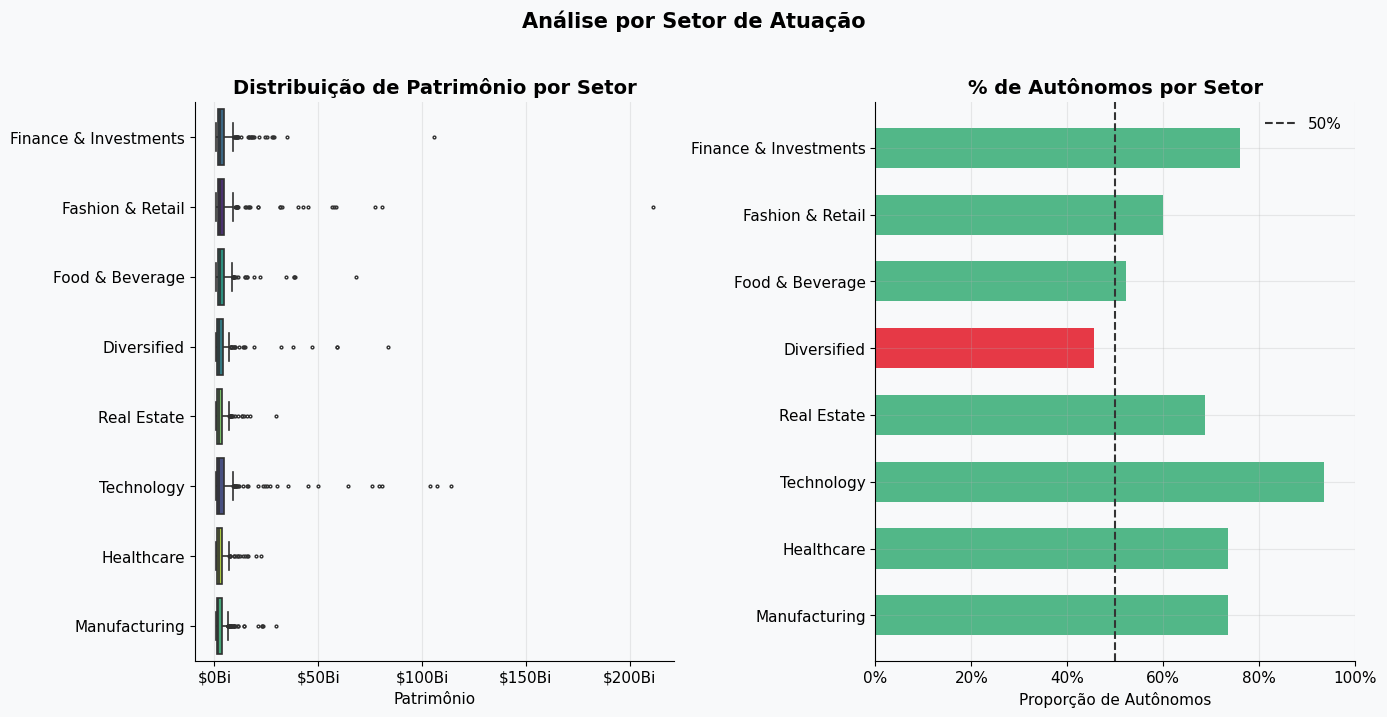

In [12]:
# ── Pergunta 4: Setor ─────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor(BG_COLOR)

top8 = df_limpo['category'].value_counts().head(8).index
df_t8 = df_limpo[df_limpo['category'].isin(top8)]

# Boxplot por setor
order_med = (df_t8.groupby('category')['finalWorth']
             .median().sort_values(ascending=False).index)
sns.boxplot(x='finalWorth', y='category', hue='category',
            data=df_t8, order=order_med, palette='viridis',
            ax=ax1, legend=False, linewidth=1.2, fliersize=2)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}Bi'))
ax1.set_title('Distribuição de Patrimônio por Setor')
ax1.set_xlabel('Patrimônio')
ax1.set_ylabel('')

# % Autônomos por setor
pct_auto = (df_t8.groupby('category')['selfMade'].mean()
            .sort_values().reindex(order_med[::-1]))
cores = [PALETTE_ORIG['Autonomo'] if v >= 0.5 else PALETTE_ORIG['Herdeiro']
         for v in pct_auto.values]
ax2.barh(pct_auto.index, pct_auto.values, color=cores, edgecolor='none', height=0.6)
ax2.axvline(0.5, color='#333', linestyle='--', lw=1.5, label='50%')
ax2.set_xlim(0, 1)
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.set_title('% de Autônomos por Setor')
ax2.set_xlabel('Proporção de Autônomos')
ax2.legend(framealpha=0)

plt.suptitle('Análise por Setor de Atuação', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Análise Combinada — Interação entre Variáveis

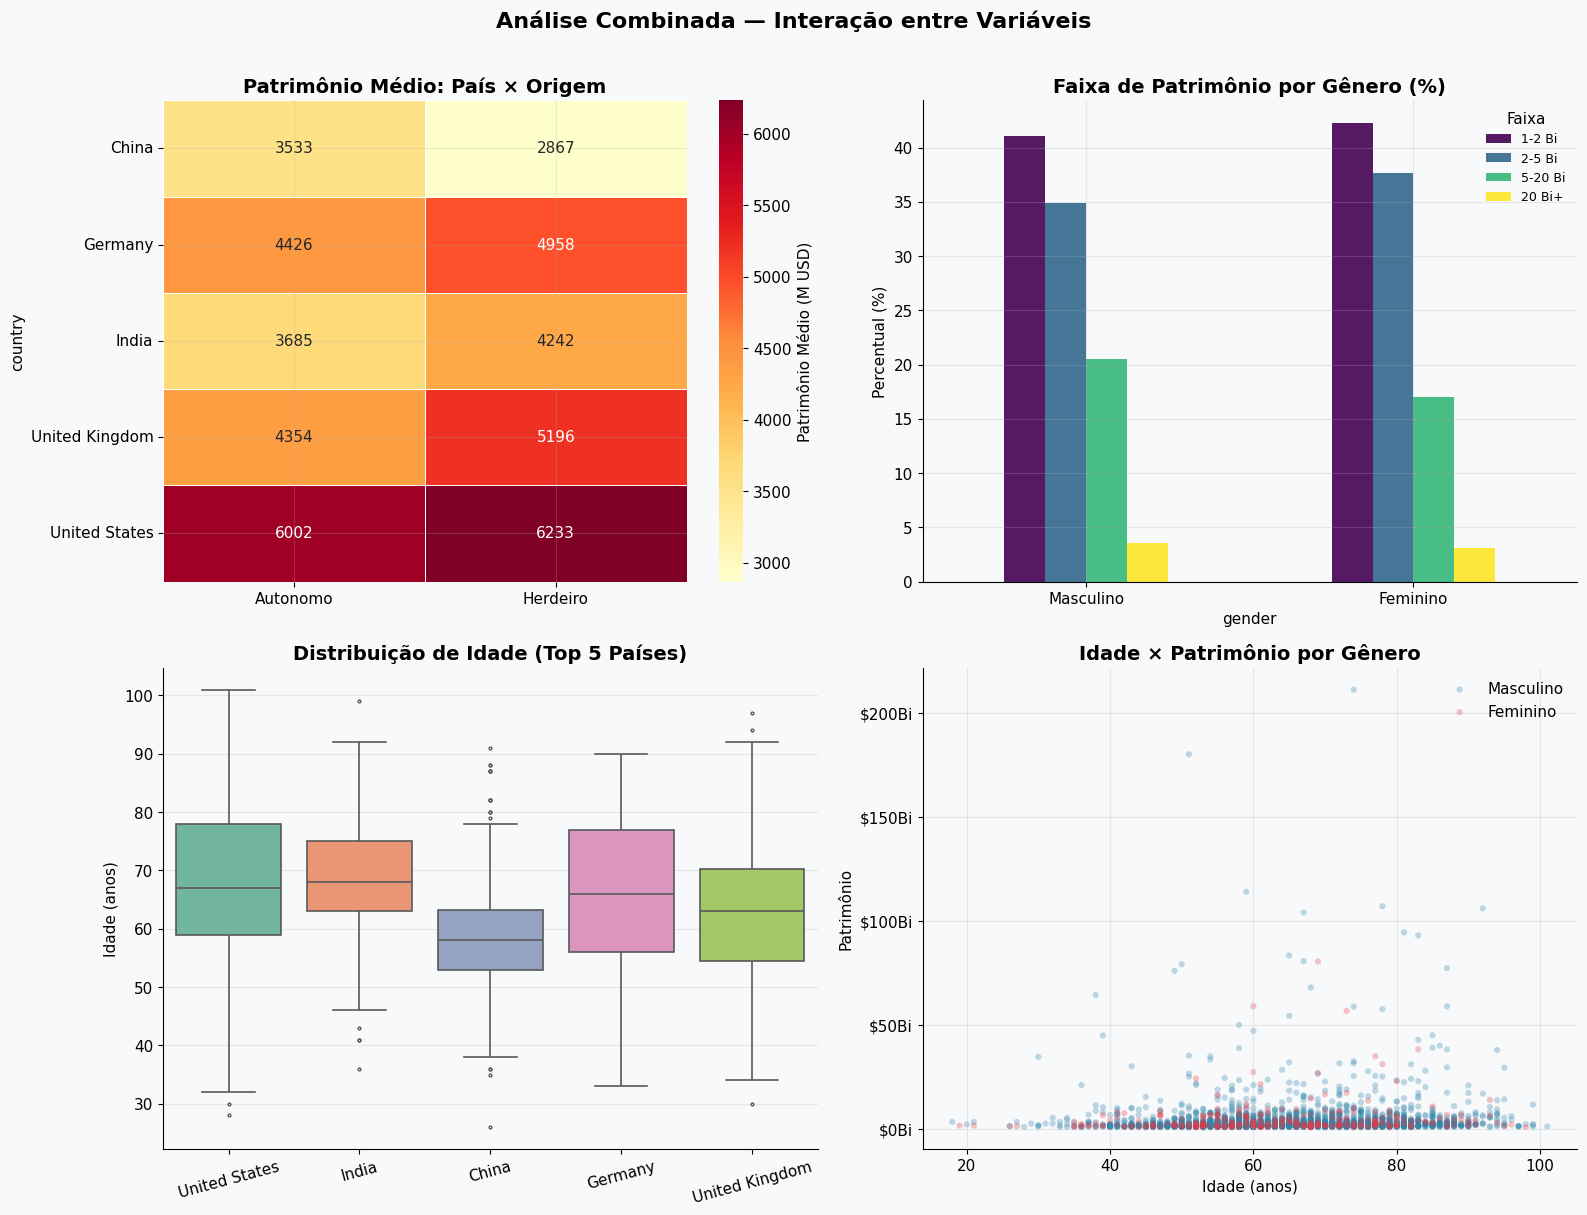

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor(BG_COLOR)

# ── Heatmap: país × origem ─────────────────────────────────────────────────
pivot_h = df_top5.pivot_table(
    values='finalWorth', index='country',
    columns='origem_riqueza', aggfunc='mean'
)
sns.heatmap(pivot_h, annot=True, fmt='.0f', cmap='YlOrRd',
            ax=axes[0,0], linewidths=0.5, cbar_kws={'label':'Patrimônio Médio (M USD)'})
axes[0,0].set_title('Patrimônio Médio: País × Origem')
axes[0,0].set_xlabel('')

# ── Barplot empilhado: gênero × faixa de patrimônio ───────────────────────
gf = (df_limpo[df_limpo['gender'].isin(['M','F'])]
      .groupby(['gender','faixa_patrimonio'], observed=True)
      .size().unstack(fill_value=0))
gf_pct = gf.div(gf.sum(axis=1), axis=0) * 100
gf_pct.plot(kind='bar', ax=axes[0,1], colormap='viridis',
            edgecolor='none', alpha=0.9)
axes[0,1].set_xticklabels(['Masculino','Feminino'], rotation=0)
axes[0,1].set_title('Faixa de Patrimônio por Gênero (%)')
axes[0,1].set_ylabel('Percentual (%)')
axes[0,1].legend(title='Faixa', framealpha=0, fontsize=9)

# ── Boxplot: país × faixa etária ──────────────────────────────────────────
sns.boxplot(x='country', y='age', hue='country',
            data=df_top5, palette='Set2',
            ax=axes[1,0], legend=False, linewidth=1.2, fliersize=2)
axes[1,0].set_title('Distribuição de Idade (Top 5 Países)')
axes[1,0].tick_params(axis='x', rotation=15)
axes[1,0].set_xlabel('')
axes[1,0].set_ylabel('Idade (anos)')

# ── Scatter: idade × patrimônio por gênero ────────────────────────────────
for g, cor in PALETTE_GEN.items():
    sub = df_limpo[df_limpo['gender']==g]
    axes[1,1].scatter(sub['age'], sub['finalWorth'],
                      c=cor, alpha=0.3, s=20,
                      label='Masculino' if g=='M' else 'Feminino',
                      edgecolors='none')
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}Bi'))
axes[1,1].set_title('Idade × Patrimônio por Gênero')
axes[1,1].set_xlabel('Idade (anos)')
axes[1,1].set_ylabel('Patrimônio')
axes[1,1].legend(framealpha=0)

plt.suptitle('Análise Combinada — Interação entre Variáveis',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Resumo Executivo

In [14]:
print("=" * 58)
print("  RESUMO EXECUTIVO — BILIONÁRIOS DO MUNDO 2023")
print("=" * 58)

print(f"\n  Total analisado  : {len(df_limpo):,} bilionários")
print(f"  Patrimônio médio : ${df_limpo['finalWorth'].mean():,.0f}M")
print(f"  Patrimônio mediano: ${df_limpo['finalWorth'].median():,.0f}M")
print(f"  Idade média       : {df_limpo['age'].mean():.1f} anos")

print("\n── GÊNERO " + "─"*47)
for g, label in [('M','Masculino'),('F','Feminino')]:
    sub = df_limpo[df_limpo['gender']==g]
    print(f"  {label:<12}: {len(sub):>5,} ({len(sub)/len(df_limpo):.1%}) | "
          f"média ${sub['finalWorth'].mean():,.0f}M")

print("\n── ORIGEM " + "─"*47)
for o in ['Autonomo','Herdeiro']:
    sub = df_limpo[df_limpo['origem_riqueza']==o]
    print(f"  {o:<12}: {len(sub):>5,} ({len(sub)/len(df_limpo):.1%}) | "
          f"mediana ${sub['finalWorth'].median():,.0f}M")

print("\n── TOP 3 PAÍSES " + "─"*41)
for pais, n in df_limpo['country'].value_counts().head(3).items():
    total = df_limpo[df_limpo['country']==pais]['finalWorth'].sum()
    print(f"  {pais:<20}: {n:>4} bilionários | total ${total/1e6:.1f}T")

print("\n── TOP 3 SETORES " + "─"*40)
for cat, n in df_limpo['category'].value_counts().head(3).items():
    media = df_limpo[df_limpo['category']==cat]['finalWorth'].mean()
    print(f"  {cat:<25}: {n:>4} | média ${media:,.0f}M")

print("\n── CONCLUSÕES " + "─"*43)
conclusoes = [
    "87% dos bilionários são homens",
    "69% construíram a própria fortuna (self-made)",
    "EUA domina em quantidade e patrimônio total",
    "Finance & Tech = setores de maior riqueza acumulada",
    "Idade média ~65 anos: riqueza extrema leva décadas",
    "Herdeiros têm patrimônio mediano MAIOR que autônomos",
]
for c in conclusoes:
    print(f"  • {c}")
print("=" * 58)

  RESUMO EXECUTIVO — BILIONÁRIOS DO MUNDO 2023

  Total analisado  : 2,575 bilionários
  Patrimônio médio : $4,679M
  Patrimônio mediano: $2,400M
  Idade média       : 65.1 anos

── GÊNERO ───────────────────────────────────────────────
  Masculino   : 2,268 (88.1%) | média $4,669M
  Feminino    :   307 (11.9%) | média $4,754M

── ORIGEM ───────────────────────────────────────────────
  Autonomo    : 1,788 (69.4%) | mediana $2,200M
  Herdeiro    :   787 (30.6%) | mediana $2,600M

── TOP 3 PAÍSES ─────────────────────────────────────────
  United States       :  754 bilionários | total $4.6T
  China               :  504 bilionários | total $1.8T
  India               :  157 bilionários | total $0.6T

── TOP 3 SETORES ────────────────────────────────────────
  Finance & Investments    :  363 | média $4,370M
  Manufacturing            :  316 | média $3,184M
  Technology               :  307 | média $6,065M

── CONCLUSÕES ───────────────────────────────────────────
  • 87% dos bilionários 

---

## Referências

- Dataset: [Billionaires Statistics Dataset — Kaggle](https://www.kaggle.com/datasets/nelgiriyewithana/billionaires-statistics-dataset)
- Bibliotecas: pandas, matplotlib, seaborn, numpy
- Curso: EMC0128/EMC0467 — IA e AIoT — UFG (2026)

---
*Notebook desenvolvido como exercício prático de visualização de dados.*